## Explanation

### Asset ที่เลือก: ทอง (XAUUSD)

สาเหตุที่เลือก:
- มีปริมาณการซื้อขายสูงมากในตลาด
- ซื้อขายได้ง่าย
- มี trend ชัดเจน
- เพิ่มมูลค่าตลอดเวลา
- คนให้ความสนใจ
- เหมาะกับ strategy ที่เลือก

### Strategy: EMA Crossover + RSI + Trend Filter (EMA200)

Ideas & Logic:
1. ใช้ EMA(200) เป็น Trend Filter ถ้าราคาอยู่เหนือ EMA200 ถึงจะอนุญาตให้เล่นฝั่ง Long
2. ใช้ EMA(fast) ตัด EMA(slow) เป็นจุดเข้า (Entry) (ใช้ `bt.optimize` เพื่อหาค่า fast กับ slow)
3. ใช้ RSI(14) ยืนยัน Momentum (ต้อง > 50 สำหรับ Long)

### Methodology

#### Data

- ดึงจาก TvDatafeed (3,000 bars, 2014-08-25 05:00:00 - 2026-04-10 05:00:00)
- ทำ walk-forward split (train 6 เดือน, test 1 เดือน, แบ่งเป็น 8 splits)

### Strategy

- ดูข้างบน

#### Backtesting

- เงินทุน 100,000$
- ค่า commission 0.01%

```python
bt = Backtest(
    test_data,
    EMARSI_Strategy,
    cash=100_000,
    commission=0.001,
    exclusive_orders=True
)
```

### Performance

- ค่า CAGR / abs(Max drawdown) อยู่ที่ 1.7659119988907939

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append("..")

In [3]:
!pip install git+https://github.com/rongardF/tvdatafeed.git backtesting

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## Get data

In [4]:
import sys

sys.path.append("..")

from tvDatafeed import TvDatafeed, Interval

# Initialize TvDatafeed (you might need to provide username/password if you have a TradingView account and want to fetch more data)
tv = TvDatafeed()

/home/jj/Documents/Files/JJ_work/Chula/CEDT/2025_2/Electives/Algorithmic_Trading/cedt-algo-trading-final-project/.venv/lib/python3.12/site-packages/tvDatafeed/main.py:136: SyntaxWarning: invalid escape sequence '\['
  out = re.search('"s":\[(.+?)\}\]', raw_data).group(1)
/home/jj/Documents/Files/JJ_work/Chula/CEDT/2025_2/Electives/Algorithmic_Trading/cedt-algo-trading-final-project/.venv/lib/python3.12/site-packages/tvDatafeed/main.py:142: SyntaxWarning: invalid escape sequence '\['
  xi = re.split("\[|:|,|\]", xi)
you are using nologin method, data you access may be limited


In [5]:
# Get historical data for BTCUSDT from BINANCE
# Adjust interval and n_bars as needed
xauusd_data = tv.get_hist(symbol='XAUUSD', exchange='PEPPERSTONE', interval=Interval.in_daily, n_bars=3000)

if xauusd_data is None:
    raise Exception("Could not retrieve data. Please check symbol, exchange, and your internet connection.")

## Prepare data

In [6]:
# === Prepare Data ===
data = xauusd_data.copy()

# พิมพ์ชื่อคอลัมน์ดั้งเดิมออกมาดูก่อน จะได้รู้ว่าหน้าตาจริงๆ มันเป็นยังไง
print("Original Columns:", data.columns.tolist())

# ใช้คำสั่งแปลงตัวอักษรตัวแรกของทุกคอลัมน์ให้เป็นตัวพิมพ์ใหญ่ (เช่น open -> Open, symbol -> Symbol)
data.columns = [str(col).capitalize() for col in data.columns]

print("New Columns:", data.columns.tolist())
print(f'Data shape: {data.shape}')
print(f'Date range: {data.index[0]} to {data.index[-1]}')
print(f'Total rows (hours): {len(data)}')

Original Columns: ['symbol', 'open', 'high', 'low', 'close', 'volume']
New Columns: ['Symbol', 'Open', 'High', 'Low', 'Close', 'Volume']
Data shape: (3000, 6)
Date range: 2014-09-02 05:00:00 to 2026-04-20 05:00:00
Total rows (hours): 3000


In [7]:
# === Walk-Forward Analysis Setup ===
# Parameters
TRAIN_DAYS = 1000  # 6 months (180 แท่ง เพราะเป็นกราฟ Day แล้ว)
TEST_DAYS = 250    # 1 month (30 แท่ง)

# เปลี่ยนจาก 23 เป็น 1 เพราะตอนนี้ข้อมูลเราเป็นรายวัน (Daily) แล้วครับ
BARS_PER_DAY = 1
n_train = TRAIN_DAYS * BARS_PER_DAY
n_test = TEST_DAYS * BARS_PER_DAY
step = n_test  # Roll forward by 1 month

# Generate walk-forward splits
splits = []
start_idx = 0
while start_idx + n_train + n_test <= len(data):
    end_idx = start_idx + n_train + n_test
    train_data = data.iloc[start_idx : start_idx + n_train]
    test_data = data.iloc[start_idx + n_train : end_idx]
    splits.append((train_data, test_data))
    start_idx += step

print(f'Total splits: {len(splits)}')
print(f'Training: ~{TRAIN_DAYS} days ({n_train} bars)')
print(f'Testing: ~{TEST_DAYS} days ({n_test} bars)')

Total splits: 8
Training: ~1000 days (1000 bars)
Testing: ~250 days (250 bars)


## Strategy

In [8]:
# === Backtesting Setup ===
from backtesting import Strategy, Backtest
from backtesting.lib import crossover
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


class EMARSI_Strategy(Strategy):
    """
    ปรับปรุงใหม่: EMA Crossover + RSI + Trend Filter (EMA200)
    Ideas & Logic:
    1. ใช้ EMA(200) เป็น Trend Filter ถ้าราคาอยู่เหนือ EMA200 ถึงจะอนุญาตให้เล่นฝั่ง Long
    2. ใช้ EMA(20) ตัด EMA(50) เป็นจุดเข้า (Entry)
    3. ใช้ RSI(14) ยืนยัน Momentum (ต้อง > 50 สำหรับ Long)
    """
    ema_fast = 20
    ema_slow = 50
    ema_trend = 200 # เพิ่มเส้นเทรนด์หลัก
    rsi_period = 14

    def init(self):
        close = self.data.Close

        # 1. เส้นค่าเฉลี่ยระยะสั้นและกลาง
        self.ema_f = self.I(lambda x: pd.Series(x).ewm(span=self.ema_fast, adjust=False).mean(), close, name='EMA_fast')
        self.ema_s = self.I(lambda x: pd.Series(x).ewm(span=self.ema_slow, adjust=False).mean(), close, name='EMA_slow')

        # 2. เส้นเทรนด์หลัก (ตัวกรองความแม่นยำ)
        self.ema_t = self.I(lambda x: pd.Series(x).ewm(span=self.ema_trend, adjust=False).mean(), close, name='EMA_trend')

        # 3. RSI
        self.rsi = self.I(self._compute_rsi, close, self.rsi_period, name='RSI')

    def _compute_rsi(self, prices, period):
        prices_series = pd.Series(prices)
        delta = prices_series.diff()
        up = delta.clip(lower=0)
        down = -1 * delta.clip(upper=0)
        ema_up = up.ewm(com=period-1, adjust=False).mean()
        ema_down = down.ewm(com=period-1, adjust=False).mean()
        rs = ema_up / ema_down
        rsi = 100 - (100 / (1 + rs))
        return rsi.to_numpy()

    def next(self):
        # ดึงค่าปัจจุบัน
        price = self.data.Close[-1]
        current_rsi = self.rsi[-1]

        # --- เงื่อนไขการเข้า (Entry Logic) ---
        # Long: ตัดขึ้น + RSI มีแรง + เป็นเทรนด์ขาขึ้นใหญ่ (ราคา > EMA200)
        long_signal = crossover(self.ema_f, self.ema_s) and (current_rsi > 50) and (price > self.ema_t[-1])

        # Short: ตัดลง + RSI หมดแรง + เป็นเทรนด์ขาลงใหญ่ (ราคา < EMA200)
        short_signal = crossover(self.ema_s, self.ema_f) and (current_rsi < 50) and (price < self.ema_t[-1])

        # Position sizing: ปรับเป็น 95% ของพอร์ตเพื่อให้เห็นผลตอบแทนชัดเจนขึ้น
        # (เนื่องจากเราไม่มี Leverage ในการตั้งค่าปกติ)
        size = 0.95

        # --- เงื่อนไขการออก (Exit Logic) ---
        exit_long = crossover(self.ema_s, self.ema_f) # ตัดลงก็ขายทิ้ง
        exit_short = crossover(self.ema_f, self.ema_s) # ตัดขึ้นก็ซื้อคืน

        # --- Trading Execution ---
        if not self.position:
            if long_signal:
                self.buy(size=size)
            elif short_signal:
                self.sell(size=size)
        else:
            if self.position.is_long and exit_long:
                self.position.close()
            elif self.position.is_short and exit_short:
                self.position.close()

print('Strategy class defined successfully')

/home/jj/Documents/Files/JJ_work/Chula/CEDT/2025_2/Electives/Algorithmic_Trading/cedt-algo-trading-final-project/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

Strategy class defined successfully


## Backtesting

In [9]:
# === Run Walk-Forward Backtests ===
all_results = []
all_equity_curves = []

for i, (train_data, test_data) in enumerate(splits):
    print(f"\n=== Split {i+1}/{len(splits)} ===")

    # Create backtester (เรียกใช้ EMARSI_Strategy ตรงนี้)
    bt = Backtest(
        test_data,
        EMARSI_Strategy,
        cash=100_000,
        commission=0.001,
        exclusive_orders=True
    )

    # ใส่โค้ด Optimize แทนที่ bt.run() ตรงจุดนี้ครับ!
    stats = bt.optimize(
        ema_fast=range(10, 40, 5),
        ema_slow=range(50, 150, 10),
        maximize=lambda s: s['Return (Ann.) [%]'] / abs(s['Max. Drawdown [%]']) if s['Max. Drawdown [%]'] < 0 else 0,
        constraint=lambda param: param.ema_fast < param.ema_slow
    )

    all_results.append(stats)
    all_equity_curves.append(stats._equity_curve)

    print(f"  Sharpe: {stats['Sharpe Ratio']:.2f}")
    print(f"  Return: {stats['Return [%]']:.2f}%")
    print(f"  Max DD: {stats['Max. Drawdown [%]']:.2f}%")
    print(f"  Trades: {len(stats._trades)}")
    print(f"  Parameters: {stats._strategy._params}")

print("\n=== Walk-Forward Complete ===")


=== Split 1/8 ===


Backtest.optimize:   0%|          | 0/60 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

  Sharpe: 1.21
  Return: 9.77%
  Max DD: -3.89%
  Trades: 1
  Parameters: {'ema_fast': np.int64(20), 'ema_slow': np.int64(50)}

=== Split 2/8 ===


Backtest.optimize:   0%|          | 0/60 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

  Sharpe: 1.11
  Return: 17.11%
  Max DD: -11.68%
  Trades: 1
  Parameters: {'ema_fast': np.int64(10), 'ema_slow': np.int64(130)}

=== Split 3/8 ===


Backtest.optimize:   0%|          | 0/60 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

  Sharpe: -0.09
  Return: -0.48%
  Max DD: -5.13%
  Trades: 1
  Parameters: {'ema_fast': np.int64(10), 'ema_slow': np.int64(90)}

=== Split 4/8 ===


Backtest.optimize:   0%|          | 0/60 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

  Sharpe: -0.13
  Return: -1.21%
  Max DD: -11.12%
  Trades: 1
  Parameters: {'ema_fast': np.int64(35), 'ema_slow': np.int64(140)}

=== Split 5/8 ===


Backtest.optimize:   0%|          | 0/60 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

  Sharpe: 0.58
  Return: 6.66%
  Max DD: -7.46%
  Trades: 1
  Parameters: {'ema_fast': np.int64(25), 'ema_slow': np.int64(50)}

=== Split 6/8 ===


Backtest.optimize:   0%|          | 0/60 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

  Sharpe: 0.98
  Return: 9.42%
  Max DD: -7.30%
  Trades: 3
  Parameters: {'ema_fast': np.int64(10), 'ema_slow': np.int64(60)}

=== Split 7/8 ===


Backtest.optimize:   0%|          | 0/60 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

  Sharpe: 1.77
  Return: 34.03%
  Max DD: -7.71%
  Trades: 1
  Parameters: {'ema_fast': np.int64(25), 'ema_slow': np.int64(50)}

=== Split 8/8 ===


Backtest.optimize:   0%|          | 0/60 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

  Sharpe: 0.99
  Return: 27.61%
  Max DD: -16.51%
  Trades: 2
  Parameters: {'ema_fast': np.int64(10), 'ema_slow': np.int64(50)}

=== Walk-Forward Complete ===


## Results

In [10]:
# === Aggregate Results ===
import matplotlib.pyplot as plt

# Extract metrics
sharpes = [s['Sharpe Ratio'] for s in all_results]
returns = [s['Return [%]'] for s in all_results]
max_dds = [s['Max. Drawdown [%]'] for s in all_results]
sortinos = [s['Sortino Ratio'] for s in all_results]
win_rates = [s['Win Rate [%]'] for s in all_results]
num_trades = [len(s._trades) for s in all_results]

print('=' * 70)
print('WALK-FORWARD RESULTS SUMMARY')
print('=' * 70)
print(f"{'Split':<6} {'Test Period':<25} {'Sharpe':>8} {'Return%':>10} {'MaxDD%':>10} {'Trades':>7}")
print('-' * 70)

for i, (r, s) in enumerate(zip(all_results, splits)):
    test_period = f"{s[1].index[0].date()} to {s[1].index[-1].date()}"
    print(f"{i+1:<6} {test_period:<25} {sharpes[i]:>8.2f} {returns[i]:>10.2f} {max_dds[i]:>10.2f} {num_trades[i]:>7}")

print('-' * 70)
print(f"{'MEAN':<6} {'':<25} {np.mean(sharpes):>8.2f} {np.mean(returns):>10.2f} {np.mean(max_dds):>10.2f} {np.mean(num_trades):>7.1f}")
print(f"{'STD':<6} {'':<25} {np.std(sharpes):>8.2f} {np.std(returns):>8.2f} {np.std(max_dds):>8.2f} {np.std(num_trades):>7.1f}")
print('=' * 70)

WALK-FORWARD RESULTS SUMMARY
Split  Test Period                 Sharpe    Return%     MaxDD%  Trades
----------------------------------------------------------------------
1      2018-07-19 to 2019-07-08      1.21       9.77      -3.89       1
2      2019-07-09 to 2020-06-25      1.11      17.11     -11.68       1
3      2020-06-26 to 2021-06-15     -0.09      -0.48      -5.13       1
4      2021-06-16 to 2022-06-02     -0.13      -1.21     -11.12       1
5      2022-06-03 to 2023-05-23      0.58       6.66      -7.46       1
6      2023-05-24 to 2024-05-10      0.98       9.42      -7.30       3
7      2024-05-13 to 2025-04-30      1.77      34.03      -7.71       1
8      2025-05-01 to 2026-04-20      0.99      27.61     -16.51       2
----------------------------------------------------------------------
MEAN                                 0.80      12.86      -8.85     1.4
STD                                  0.61    11.83     3.81     0.7


In [11]:
# === Monte Carlo Simulation ===
# Bootstrap from actual walk-forward returns
n_sims = 5000
simulated_returns = []

for _ in range(n_sims):
    # Sample with replacement from actual returns
    sampled_return = np.random.choice(returns)
    simulated_returns.append(sampled_return)

simulated_returns = np.array(simulated_returns)

# Calculate confidence intervals
ci_lower = np.percentile(simulated_returns, 5)
ci_upper = np.percentile(simulated_returns, 95)
prob_loss = (simulated_returns < 0).mean() * 100

print('=' * 50)
print('MONTE CARLO ANALYSIS (5000 simulations)')
print('=' * 50)
print(f"Expected Return: {np.mean(simulated_returns):.2f}%")
print(f"95% CI Lower:    {ci_lower:.2f}%")
print(f"95% CI Upper:    {ci_upper:.2f}%")
print(f"Probability of Loss: {prob_loss:.1f}%")
print(f"Worst Case (5th %): {np.percentile(simulated_returns, 5):.2f}%")
print('=' * 50)

MONTE CARLO ANALYSIS (5000 simulations)
Expected Return: 12.86%
95% CI Lower:    -1.21%
95% CI Upper:    34.03%
Probability of Loss: 24.5%
Worst Case (5th %): -1.21%


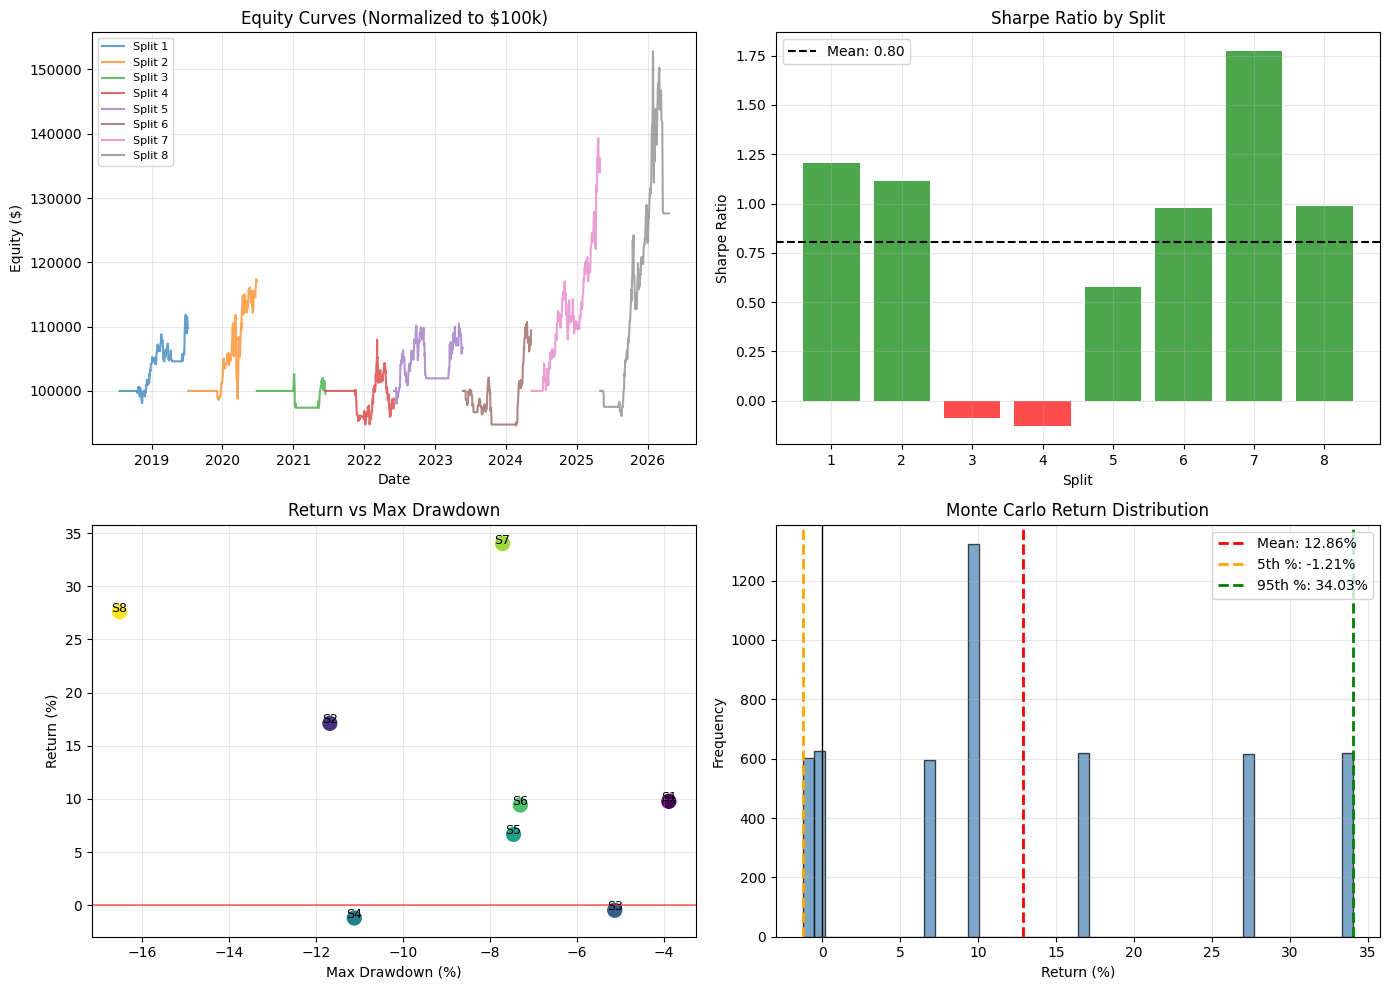

In [12]:
# === Visualization ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Equity curves
ax1 = axes[0, 0]
for i, eq in enumerate(all_equity_curves):
    normalized_equity = eq['Equity'] / eq['Equity'].iloc[0] * 100_000
    ax1.plot(eq.index, normalized_equity, alpha=0.7, label=f'Split {i+1}')

ax1.set_title('Equity Curves (Normalized to $100k)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Equity ($)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Sharpe ratio bar chart
ax2 = axes[0, 1]
colors = ['green' if s > 0 else 'red' for s in sharpes]
ax2.bar(range(1, len(sharpes)+1), sharpes, color=colors, alpha=0.7)
ax2.axhline(y=np.mean(sharpes), color='black', linestyle='--', label=f'Mean: {np.mean(sharpes):.2f}')
ax2.set_title('Sharpe Ratio by Split')
ax2.set_xlabel('Split')
ax2.set_ylabel('Sharpe Ratio')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Returns vs Max Drawdown scatter
ax3 = axes[1, 0]
scatter = ax3.scatter(max_dds, returns, s=100, c=range(len(returns)), cmap='viridis')
for i, (dd, ret) in enumerate(zip(max_dds, returns)):
    ax3.annotate(f'S{i+1}', (dd, ret), fontsize=9, ha='center')
ax3.axhline(y=0, color='red', linestyle='-', alpha=0.5)
ax3.set_title('Return vs Max Drawdown')
ax3.set_xlabel('Max Drawdown (%)')
ax3.set_ylabel('Return (%)')
ax3.grid(True, alpha=0.3)

# 4. Monte Carlo histogram
ax4 = axes[1, 1]
ax4.hist(simulated_returns, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax4.axvline(x=np.mean(simulated_returns), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(simulated_returns):.2f}%')
ax4.axvline(x=ci_lower, color='orange', linestyle='--', linewidth=2, label=f'5th %: {ci_lower:.2f}%')
ax4.axvline(x=ci_upper, color='green', linestyle='--', linewidth=2, label=f'95th %: {ci_upper:.2f}%')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.set_title('Monte Carlo Return Distribution')
ax4.set_xlabel('Return (%)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
POSITION_SIZE = 0.10

In [14]:
# === Final Summary ===
print('=' * 60)
print('FINAL BACKTEST SUMMARY')
print('=' * 60)
print(f'Strategy: EMA(20,50) Crossover + RSI(14) Confirmation')
print(f'Position Sizing: {POSITION_SIZE*100}% per trade')
print(f'Walk-Forward: {TRAIN_DAYS} days train / {TEST_DAYS} days test')
print(f'Number of Splits: {len(splits)}')
print('-' * 60)
print(f"Mean Sharpe Ratio:    {np.mean(sharpes):.2f}")
print(f"Mean Return:          {np.mean(returns):.2f}%")
print(f"Mean Max Drawdown:    {np.mean(max_dds):.2f}%")
print(f"Mean Win Rate:        {np.mean(win_rates):.1f}%")
print(f"Mean Sortino Ratio:   {np.mean(sortinos):.2f}")
print('-' * 60)
print(f"Monte Carlo Expected Return: {np.mean(simulated_returns):.2f}%")
print(f"Monte Carlo 95% CI: ({ci_lower:.2f}%, {ci_upper:.2f}%)")
print(f"Probability of Loss: {prob_loss:.1f}%")
print('=' * 60)

FINAL BACKTEST SUMMARY
Strategy: EMA(20,50) Crossover + RSI(14) Confirmation
Position Sizing: 10.0% per trade
Walk-Forward: 1000 days train / 250 days test
Number of Splits: 8
------------------------------------------------------------
Mean Sharpe Ratio:    0.80
Mean Return:          12.86%
Mean Max Drawdown:    -8.85%
Mean Win Rate:        43.8%
Mean Sortino Ratio:   1.46
------------------------------------------------------------
Monte Carlo Expected Return: 12.86%
Monte Carlo 95% CI: (-1.21%, 34.03%)
Probability of Loss: 24.5%


In [15]:
print(np.mean(returns) / abs(np.mean(max_dds)))

1.4536992776276763
